(np.float64(-0.5), np.float64(1023.5), np.float64(1279.5), np.float64(-0.5))

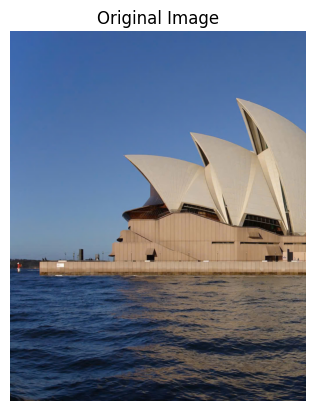

In [62]:
import numpy as np
import cv2
import matplotlib.pyplot as Vu   # thay bằng tên sinh viên

# đọc ảnh
img = cv2.imread('img1.jpg')

# hiển thị ảnh
Vu.imshow(img[:,:,::-1])
Vu.title("Original Image")
Vu.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(1279.5), np.float64(-0.5))

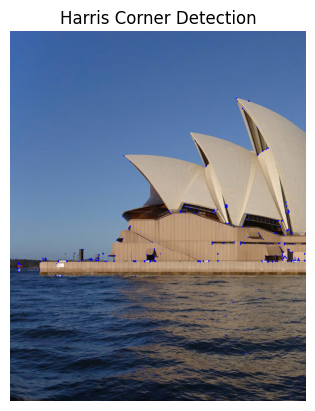

In [63]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Harris
dst = cv2.cornerHarris(gray,2,3,0.04)

# giãn kết quả
dst = cv2.dilate(dst,None)

img_harris = img.copy()
img_harris[dst>0.01*dst.max()] = [255,0,0]

Vu.imshow(img_harris[:,:,::-1])
Vu.title("Harris Corner Detection")
Vu.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(1279.5), np.float64(-0.5))

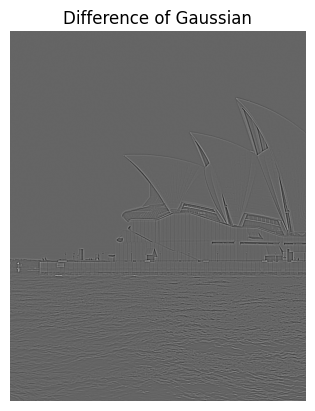

In [64]:
blur1 = cv2.GaussianBlur(gray,(5,5),1)
blur2 = cv2.GaussianBlur(gray,(9,9),2)

dog = blur1 - blur2

Vu.imshow(dog, cmap='gray')
Vu.title("Difference of Gaussian")
Vu.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(1279.5), np.float64(-0.5))

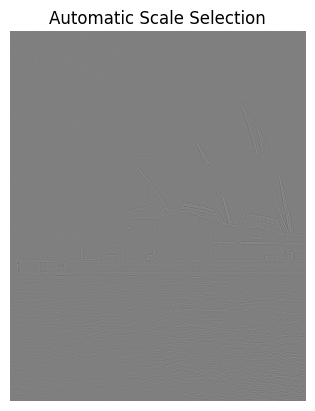

In [65]:
gray_uint8 = np.uint8(gray)

log = cv2.Laplacian(gray_uint8, cv2.CV_64F)

Vu.imshow(log, cmap='gray')
Vu.title("Automatic Scale Selection")
Vu.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(1279.5), np.float64(-0.5))

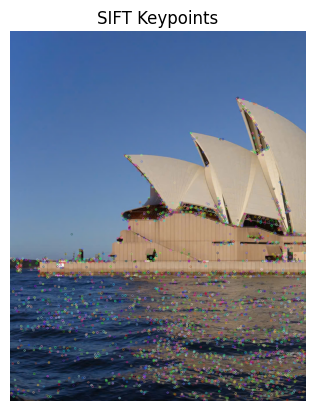

In [66]:
gray_sift = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray_sift, None)

img_sift = cv2.drawKeypoints(img, kp, None)

Vu.imshow(img_sift[:,:,::-1])
Vu.title("SIFT Keypoints")
Vu.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(1279.5), np.float64(-0.5))

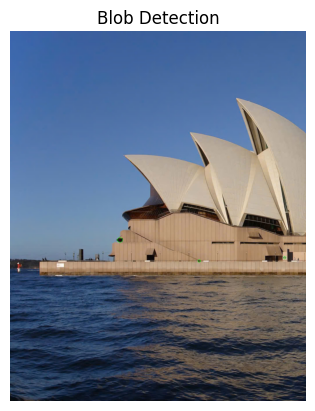

In [67]:
gray_blob = np.uint8(gray)

keypoints = detector.detect(gray_blob)

img_blob = cv2.drawKeypoints(
    img, keypoints, np.array([]),
    (0,255,0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

Vu.imshow(img_blob[:,:,::-1])
Vu.title("Blob Detection")
Vu.axis("off")

In [68]:
from sklearn.cluster import KMeans

features = des

k = 20
kmeans = KMeans(n_clusters=k)
kmeans.fit(features)

histogram = np.bincount(kmeans.labels_, minlength=k)

print("Histogram BoW:", histogram)

Histogram BoW: [105 279 307 127 230 216 223 180 156 116 131 193  68 231 118 129 246 111
 113 151]


(np.float64(-0.5), np.float64(2098.5), np.float64(1279.5), np.float64(-0.5))

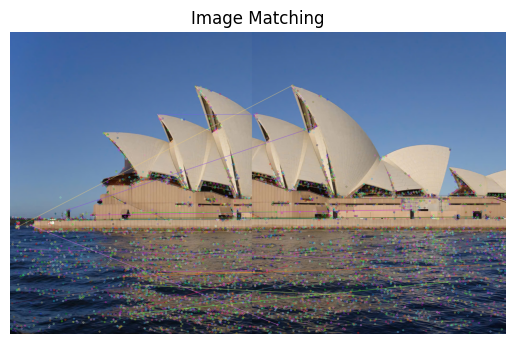

In [69]:
img1 = cv2.imread('img1.jpg')
img2 = cv2.imread('img2.jpg')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1,None)
kp2, des2 = sift.detectAndCompute(gray2,None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)

good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

img_match = cv2.drawMatches(img1,kp1,img2,kp2,good[:20],None)

Vu.imshow(img_match[:,:,::-1])
Vu.title("Image Matching")
Vu.axis("off")

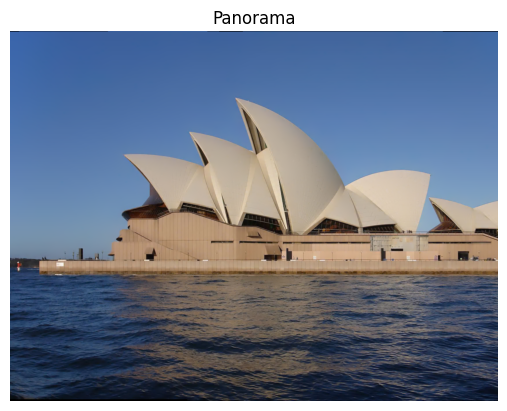

In [70]:
stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img1,img2])

if status == cv2.STITCHER_OK:
    Vu.imshow(pano[:,:,::-1])
    Vu.title("Panorama")
    Vu.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(1279.5), np.float64(-0.5))

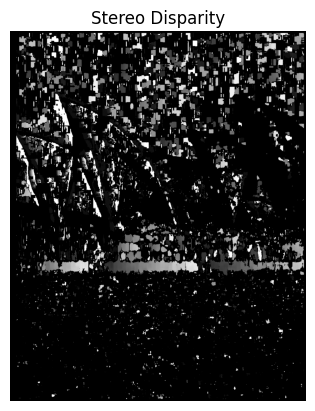

In [71]:
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)

# đảm bảo cùng kích thước
gray2 = cv2.resize(gray2, (gray1.shape[1], gray1.shape[0]))

disparity = stereo.compute(gray1, gray2)

Vu.imshow(disparity, cmap='gray')
Vu.title("Stereo Disparity")
Vu.axis("off")

In [72]:
hist1 = cv2.calcHist([img1],[0],None,[256],[0,256])
hist2 = cv2.calcHist([img2],[0],None,[256],[0,256])

similarity = cv2.compareHist(hist1,hist2,cv2.HISTCMP_CORREL)

print("Similarity:", similarity)

Similarity: 0.9278953773040807


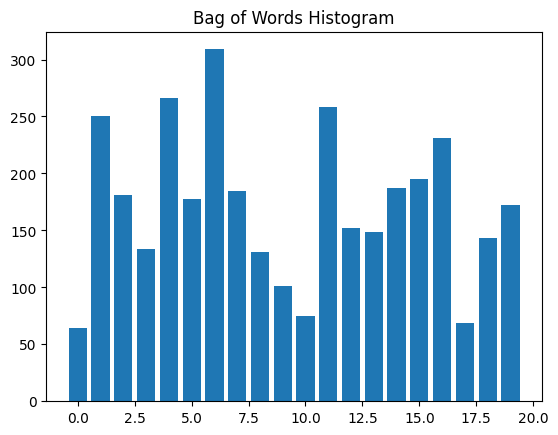

In [73]:
from sklearn.cluster import KMeans

# đảm bảo ảnh đúng kiểu
gray_sift = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

kp, des = sift.detectAndCompute(gray_sift, None)

# tránh lỗi nếu SIFT không tìm được feature
if des is None:
    print("Không tìm thấy feature")
else:
    kmeans = KMeans(n_clusters=20)
    kmeans.fit(des)

    bow_hist = np.bincount(kmeans.labels_, minlength=20)

    Vu.bar(range(20), bow_hist)
    Vu.title("Bag of Words Histogram")